In [15]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score
from sklearn.model_selection import KFold, StratifiedKFold
from transformers import pipeline, AutoModelForCausalLM, AutoTokenizer
import warnings
warnings.filterwarnings('ignore')

print(f"GPU disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Modelo de GPU: {torch.cuda.get_device_name(0)}")

corpus = pd.read_csv('C:/Users/inqui/OneDrive/Desktop/Clases/26-2/LLM_PROJECT_1/data/processed_v2/infraestructura_limpio.csv',
                     usecols = ['comentario', 'rango_humano'],encoding = 'utf-8-sig')
print(corpus.head())

GPU disponible: False
                                          comentario  rango_humano
0  cuál es el más cercado para rayar el nombre de...           3.0
1  esos baños deberian estar en el metro, no sabe...           2.0
2  ????????????????????????????????????no pues bu...           3.0
3                                los van a abandonar           2.0
4                           Nada los tiene contentos           4.0


In [5]:
analizador = pipeline(
    "sentiment-analysis",
#    model = 'citizenlab/distilbert-base-multilingual-cased-toxicity' #podria funcionar con un tuneo
#    model ="BAAI/bge-reranker-v2-m3" #no sirve para el objetivo
#    model = openai-community/gpt2 #no compro ni por barato
#    model="distilbert-base-uncased-finetuned-sst-2-english" #el que usa el profe. podria funcionar tuneado
    model = 'nlptown/bert-base-multilingual-uncased-sentiment', #podria funcionar con un tuneo, el mas prometedor por ahora    
#    model = "FacebookAI/roberta-large-mnli", #puede prometer
#    model = 'FacebookAI/xlm-roberta-large', #demasiado crudo
#    model = 'cardiffnlp/twitter-roberta-base-sentiment-latest', #podria ser, pero hay que enseñarle español
#    model = 'Bhumika/roberta-base-finetuned-sst2',
    torch_dtype="auto",           # Detecta automáticamente el tipo óptimo
#    device_map="auto"             # Coloca el modelo en GPU si está disponible
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [6]:
etiqueta = []
confianza = []

for texto in list(corpus['comentario']):
    try:
        aux = analizador(texto)[0]
        etiqueta.append(aux['label'])
        confianza.append(aux['score'])
    except:
        print(texto, type(texto))

Vamos ahora con el calculo de las metricas del baseline

In [7]:
resultados = pd.DataFrame({'Comentario':list(corpus['comentario']),'Puntuacion Estimada': [float(etiq[0]) for etiq in etiqueta],
                           'Puntuacion Real':corpus['rango_humano'],'Confianza':confianza})

print(resultados)
#resultados.to_csv('C:/Users/inqui/OneDrive/Desktop/borrar.csv')
print('--------------------------------------------------------------------')
#print(resultados.dropna())


#aqui se hace la comparacion promedio de atinados y predichos, matriz de confusion, etc...


                                            Comentario  Puntuacion Estimada  \
0    cuál es el más cercado para rayar el nombre de...                  5.0   
1    esos baños deberian estar en el metro, no sabe...                  1.0   
2    ????????????????????????????????????no pues bu...                  1.0   
3                                  los van a abandonar                  1.0   
4                             Nada los tiene contentos                  1.0   
..                                                 ...                  ...   
896                                         ??????????                  1.0   
897  Hay al ratito van a decir que costo mil de mil...                  1.0   
898  Pov comienzan a cerrar estaciones estoy segura...                  1.0   
899                      esos serán moteles no se agan                  1.0   
900                                         comentario                  3.0   

     Puntuacion Real  Confianza  
0                

                       precision    recall  f1-score   support

             negativa       0.82      0.19      0.31       139
parcialmente negativo       0.14      0.58      0.23        19
              neutral       0.07      0.38      0.11        16
parcialmente negativo       0.12      0.12      0.12        17
             positiva       0.00      0.00      0.00        29

             accuracy                           0.21       220
            macro avg       0.23      0.25      0.15       220
         weighted avg       0.54      0.21      0.24       220

0.2531678063122258


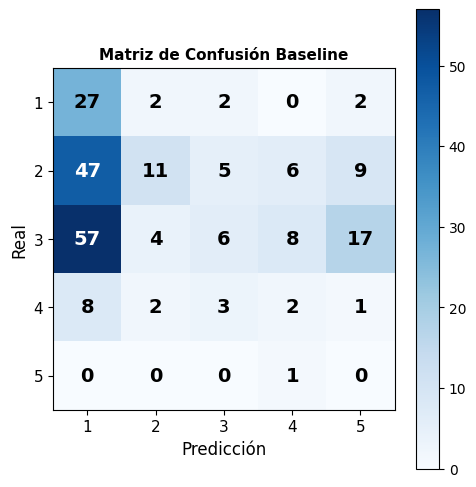

In [19]:
muestra = resultados[np.isnan(corpus['rango_humano']) == False]
# print(muestra)
semilla = 61298

print(classification_report(muestra['Puntuacion Estimada'], muestra['Puntuacion Real'],
                             target_names = ['negativa','parcialmente negativo',
                             'neutral','parcialmente negativo', 'positiva']))
print(balanced_accuracy_score(muestra['Puntuacion Estimada'], muestra['Puntuacion Real']))

# Matriz de confusión
orden = [1,2,3,4,5]
nombres = ['negativa','parcialmente negativo',
           'neutral','parcialmente negativo', 'positiva']
cm = confusion_matrix(muestra['Puntuacion Real'],
                      muestra['Puntuacion Estimada'], labels=orden)



fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(5)); ax.set_xticklabels(orden, fontsize=11)
ax.set_yticks(range(5)); ax.set_yticklabels(orden, fontsize=11)
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title('Matriz de Confusión Baseline',
             fontsize=11, fontweight='bold')
for i in range(5):
    for j in range(5):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                fontsize=14, fontweight='bold',
                color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.colorbar(im)
plt.tight_layout()
plt.show()